# W18

### part 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

Text(0, 0.5, '$\\mu$')

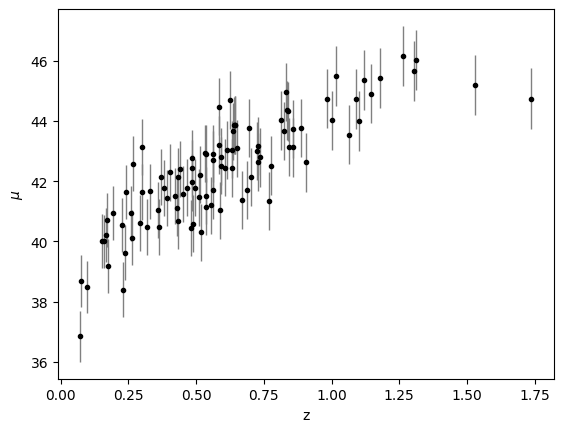

In [2]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")

In [4]:
kernel = RBF(length_scale=0.5, length_scale_bounds=(0.1, 10.0)) + WhiteKernel(noise_level=1.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, normalize_y=True)
gp.fit(z_sample[:, np.newaxis], mu_sample)

/Users/lorenzaimpicicche/.pyenv/versions/3.10.11/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=array([0.84387183, 0.91812087, 0.89001003, 0.94522717, 0.94422381,
       0.86154897, 0.86230499, 0.94838417, 0.9933467 , 0.9646779 ,
       0.87701523, 0.89976228, 0.92772472, 0.93248803, 0.87910942,
       0.90886653, 0.90007965, 0.74796941, 0.94290888, 0.96641079,
       0.87820976, 0.91709206, 0.80479835, 0.87887073, 0.98216481,
       0.92265029, 0.8835475 , 0.94586178, 0.86985...
       0.93684146, 0.91281498, 0.89527413, 0.81855684, 0.85259287,
       0.97119502, 0.88669278, 0.90504074, 0.72518962, 0.86689404,
       0.88987903, 0.91659546, 0.97685316, 0.91867826, 0.93138181,
       0.83270862, 0.93814442, 0.95430226, 0.9199094 , 0.89010136,
       0.83350663, 0.90995601, 0.90388843, 0.98995206, 0.89661359,
       0.90000008, 0.90519576, 0.95184399, 0.79454928, 0.92548723]),
                         kernel=RBF(length_scale=0.5) + WhiteKernel(noise_level=1),
                         normalize_y=True)

In [5]:
z_pred = np.linspace(0, 2, 500)
mu_pred, mu_std = gp.predict(z_pred[:, np.newaxis], return_std=True)

Text(0, 0.5, '$\\mu$')

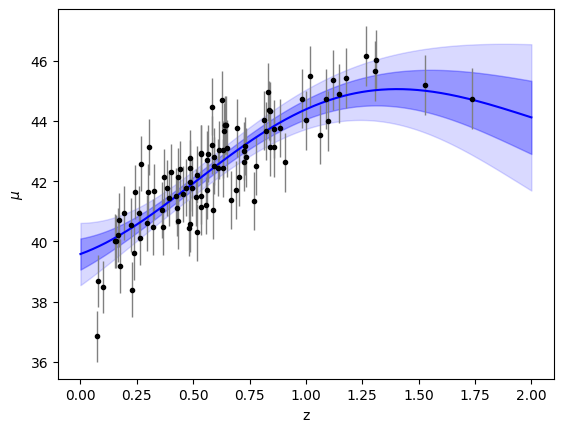

In [6]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_pred, mu_pred, 'b-', label='GPR mean')
plt.fill_between(z_pred, mu_pred - mu_std, mu_pred + mu_std, color='blue', alpha=0.3, label=r'1$\sigma$')
plt.fill_between(z_pred, mu_pred - 2*mu_std, mu_pred + 2*mu_std, color='blue', alpha=0.15, label=r'2$\sigma$')
plt.xlabel("z")
plt.ylabel(r"$\mu$")

In [7]:
z_clone = np.random.choice(z_sample, size=1000, replace=True)
mu_clone, mu_clone_std = gp.predict(z_clone[:, np.newaxis], return_std=True)
mu_clone_sim = np.random.normal(mu_clone, mu_clone_std)

Text(0, 0.5, '$\\mu$')

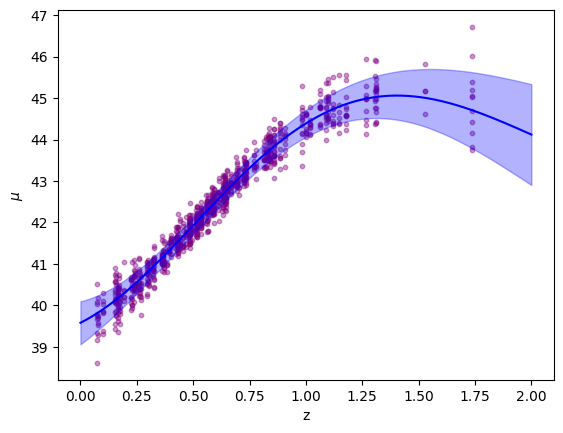

In [8]:
plt.scatter(z_clone, mu_clone_sim, color='purple', alpha=0.4, s=10, label='Cloned data')
plt.plot(z_pred, mu_pred, 'b-', label='GPR mean')
plt.fill_between(z_pred, mu_pred - mu_std, mu_pred + mu_std, color='blue', alpha=0.3, label=r'1$\sigma$')
plt.xlabel("z")
plt.ylabel(r"$\mu$")

### part 3

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
import emcee
import corner
import dynesty
from dynesty import utils as dyfunc
from astroML.datasets import generate_mu_z

In [32]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)
c = 3e5  #km/s

In [33]:
def mu_theory(z, H0, Om):
    Ez_inv=lambda zp: 1./np.sqrt(Om*(1+zp)**3+(1-Om))
    integral=np.array([quad(Ez_inv, 0, zi)[0] for zi in z])
    dL=(c/H0)*(1+z)*integral
    return 5*np.log10(dL)+25

In [34]:
def log_likelihood(theta):
    Om, H0 = theta
    if Om <= 0 or H0 <= 0:
        return -np.inf
    mu_model = mu_theory(z_sample, H0, Om)
    return np.sum(norm(mu_model, dmu).logpdf(mu_sample))

In [35]:
def log_prior(theta):
    Om, H0 = theta
    if 0.1 < Om < 1.0 and 50 < H0 < 100:
        return 0.0
    return -np.inf

In [36]:
def log_posterior(theta):
    return log_prior(theta) + log_likelihood(theta)

1525it [00:17, 86.81it/s, +500 | bound: 0 | nc: 1 | ncall: 10503 | eff(%): 20.244 | loglstar:   -inf < -132.814 <    inf | logz: -135.006 +/-  0.040 | dlogz:  0.001 >  0.509]


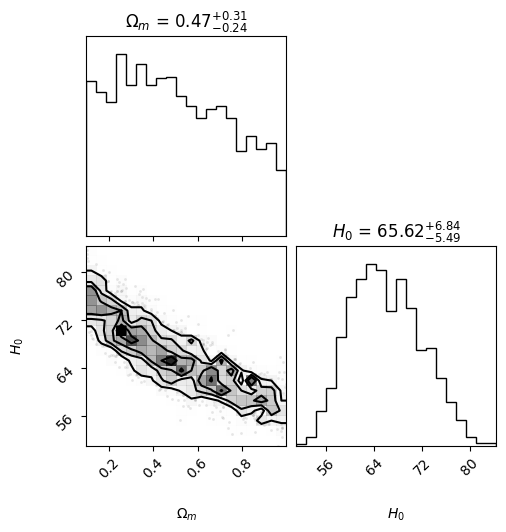

In [37]:
def prior_transform(u):
    return np.array([0.1 + u[0]*0.9, 50 + u[1]*50])

dsampler = dynesty.NestedSampler(log_likelihood, prior_transform, ndim=2, nlive=500)
dsampler.run_nested()
dresults = dsampler.results

samples = dresults.samples
weights = np.exp(dresults.logwt - dresults.logz[-1])
samples_equal = dyfunc.resample_equal(samples, weights)

corner.corner(samples_equal, labels=["$\\Omega_m$", "$H_0$"], show_titles=True)
plt.show()